# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** October 31, 2025 <br>
**Objective:** Data inspection, exploration, and preparation for training/test splits.


## Introduction
This project uses seaborn's Titanic dataset to demonstrate pre-processing of data before splitting for analysis and to compare splitting methods.  We will inspect and clean the data before comparing standard pseudo-random splitting to stratified spliting.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree

from stats_jordan import classification_table


## Section 1. Load and Inspect the Data

### 1.1 Load the Dataset
Next, we load the Mushroom dataset from seaborn and view its head.

In [2]:
titanic_df: pd.DataFrame = sns.load_dataset('titanic')  # noqa: Q000

titanic_df.head(10)
# Load the mushroom dataset
mushroom_df: pd.DataFrame = pd.read_csv("../../data/agaricus-lepiota.data", header=None, na_values="?")
# Display the first 10 rows of the dataset
mushroom_df.columns = ["poisonous", "cap-shape", "cap-surface", "cap-color", "bruises?", "odor",
                       "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
                       "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
                       "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
                       "ring-number", "ring-type", "spore-print-color", "population", "habitat"]

mushroom_df.head(10)

,poisonous,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


### 1.2 Preliminary Inspection

Then, we check for missing values, display summary statistics, and check for correlations.

In [3]:
# Check data types and missing values
mushroom_df.info(verbose=True)
# Summary statistics
display(mushroom_df.describe())
# Check for missing values
display(mushroom_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises?                  8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,poisonous,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


poisonous                      0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises?                       0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

### Reflection 1:

1) What do you notice about the dataset? 
2) Are there any data issues?

## Section 2. Explore data patterns and distributions

Now, we will explore our dataset with charts.  Depending on what we learn, cleaning and/or feature engineering may be in order.

odor, gill size, spore print color

### 2.1 Create Scatter Matrix, Scatter Plot, Histogram and Count Plot

We create a scatter matrix for the numeric attributes.

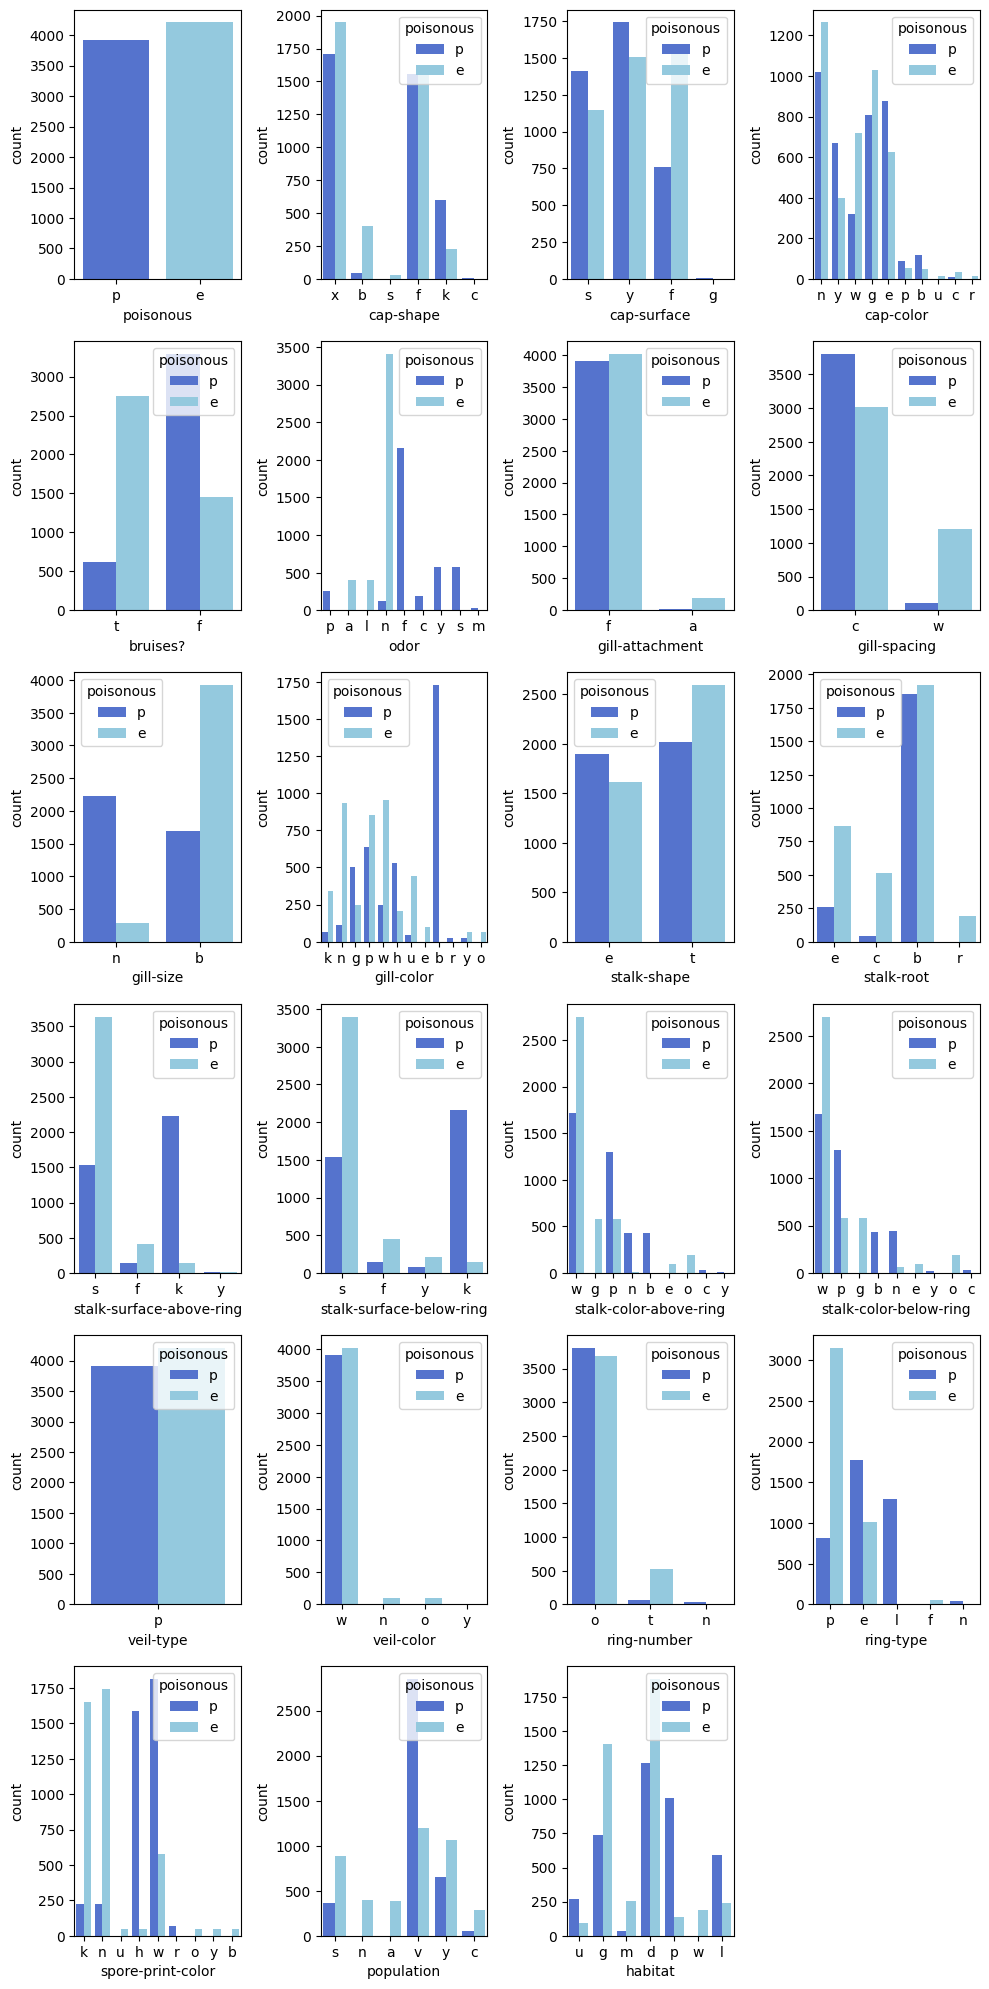

In [4]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(10,20))
axes = axes.flatten()

for idx, col in enumerate(mushroom_df.columns):

    sns.countplot(x=col, hue="poisonous", data=mushroom_df, ax=axes[idx], palette=["royalblue","skyblue"])

axes[-1].set_axis_off()
plt.tight_layout()
plt.show()

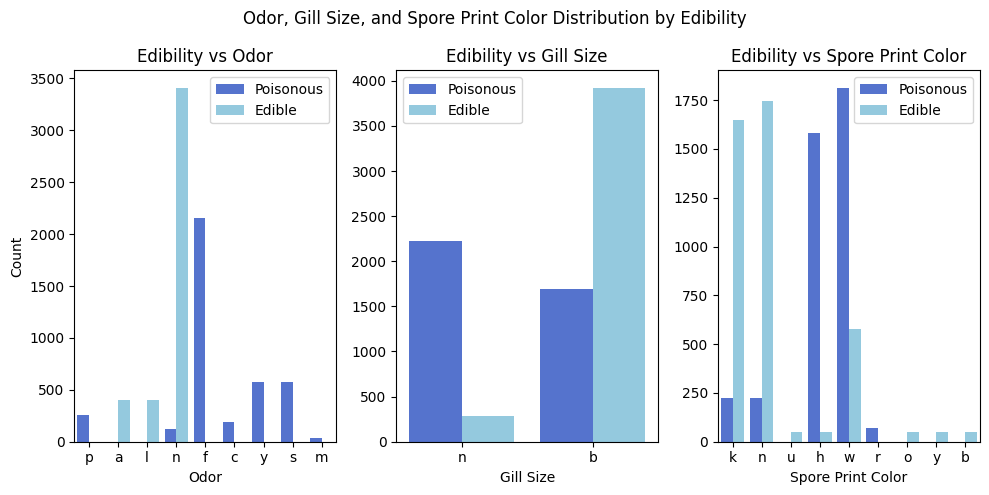

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10,5))

for ax, col in zip(axes.flatten(), ("odor", "gill-size", "spore-print-color"), strict=True):

    sns.countplot(x=col, hue="poisonous", data=mushroom_df, ax=ax, palette=["royalblue","skyblue"])
    ax.set_title(f"Edibility vs {col.replace("-", " ").title()}")
    ax.set_ylabel("Count") if ax is axes[0] else ax.set_ylabel("")
    ax.set_xlabel(col.replace("-", " ").title())
    ax.legend(handles=ax.get_legend_handles_labels()[0], labels=["Poisonous", "Edible"])

fig.suptitle("Odor, Gill Size, and Spore Print Color Distribution by Edibility")
plt.tight_layout()
plt.show()

### 2.2 Handle Missing Values and Clean Data

The 'age' and 'embark_town' features had missing values, so we impute missing age values using the median and fill missing 'embark_town' values with the mode.

In [6]:
class_names: dict = {
    "odor": {"a": "almond", "l": "anise", "c": "creosote", "y": "fishy", "f": "foul",
             "m": "musty", "n": "none", "p": "pungent", "s": "spicy"},
    "spore-print-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "r": "green",
                          "o": "orange", "u": "purple", "w": "white", "y": "yellow"},
    "gill-size": {"b": "broad", "n": "narrow"}
}

X = pd.get_dummies(mushroom_df[class_names.keys()].replace(class_names), columns = list(class_names.keys()))

y = mushroom_df["poisonous"].map({"p": 1, "e": 0})


### Reflection 2:

What patterns or anomalies do you see? Do any features stand out? What preprocessing steps were necessary to clean and improve the data? Did you create or modify any features to improve performance?



## Section 3. Choose Features and Target

With classification in mind, we now select input and target features for our model.


### 3.1 Choose Features and Target


dfdfd

### 3.2 Define X and y



In [7]:
X1 = X.filter(regex="^spore-print-color_")

X2 = X.filter(regex="^spore-print-color_|odor_")

X3 = X


Reflection 3:

Why did you choose these features? How might they impact predictions or accuracy?

## Section 4. Train and Evaluate Decision Tree Models

We will now split the data into training and test sets using train_test_split first and StratifiedShuffleSplit second.  Then a comparison of the results will be performed.


### 4.1 Split the Data

In [8]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx, test_idx in splitter.split(X3, y):

    X1_train = X1.iloc[train_idx]
    X1_test = X1.iloc[test_idx]

    X2_train = X2.iloc[train_idx]
    X2_test = X2.iloc[test_idx]

    X3_train = X3.iloc[train_idx]
    X3_test = X3.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

### 4.2 Train Decision Tree Models

In [ ]:
# CASE 1: Decision Tree using
tree_model1 = DecisionTreeClassifier(random_state=123)
tree_model1.fit(X1_train, y_train)

# CASE 2: Decision Tree using
tree_model2 = DecisionTreeClassifier(random_state=123)
tree_model2.fit(X2_train, y_train)

# CASE 3: Decision Tree using
tree_model3 = DecisionTreeClassifier(random_state=123)
tree_model3.fit(X3_train, y_train);

### 4.3 Evaluate Performance

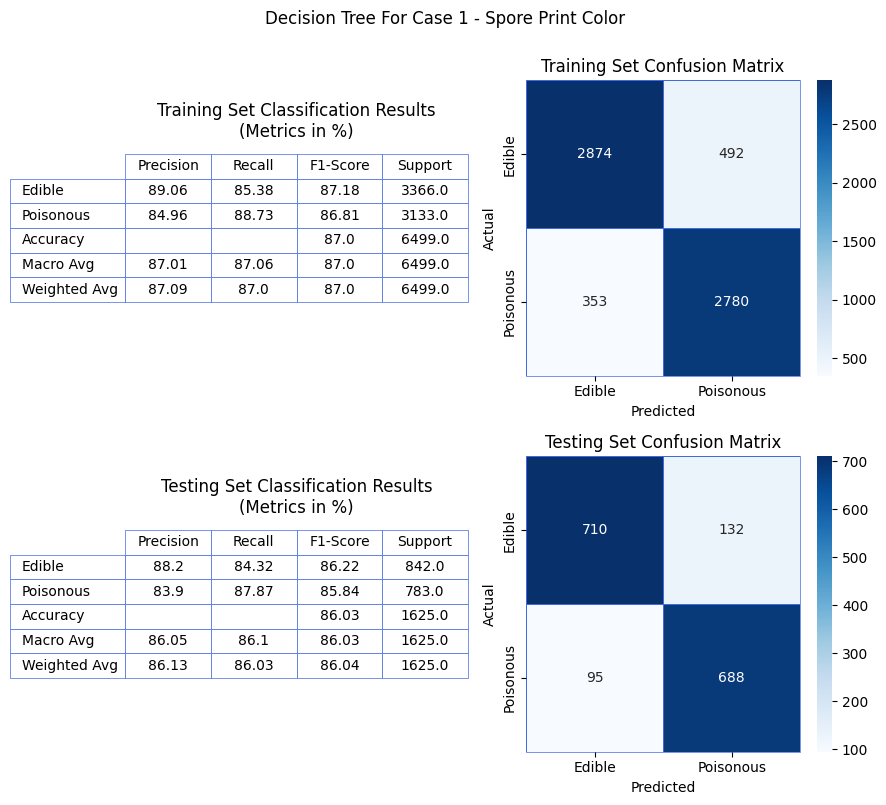

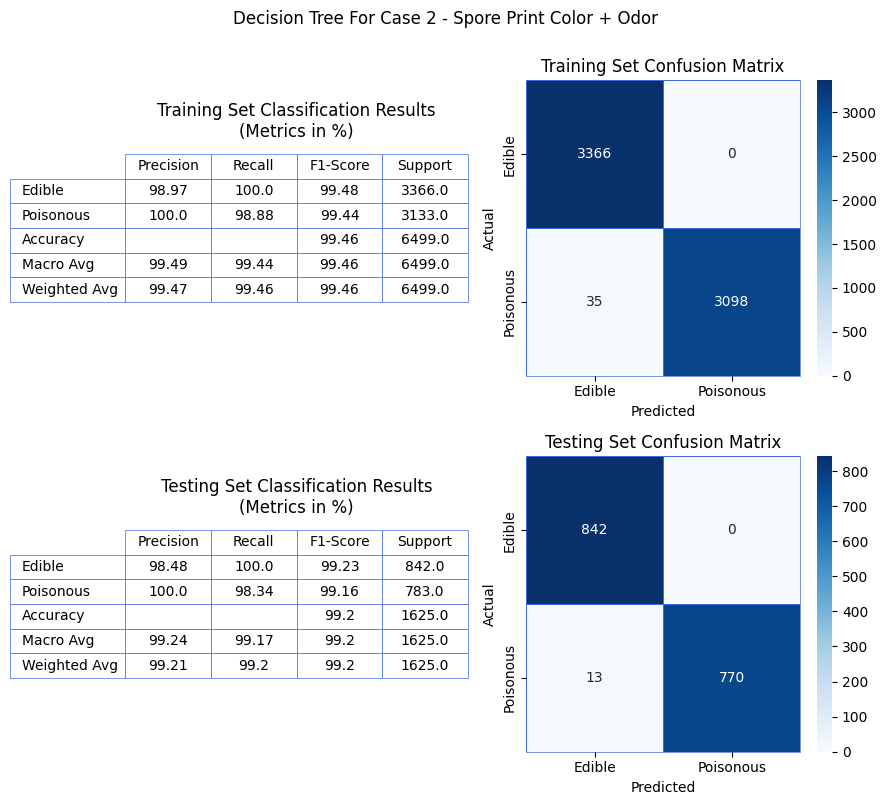

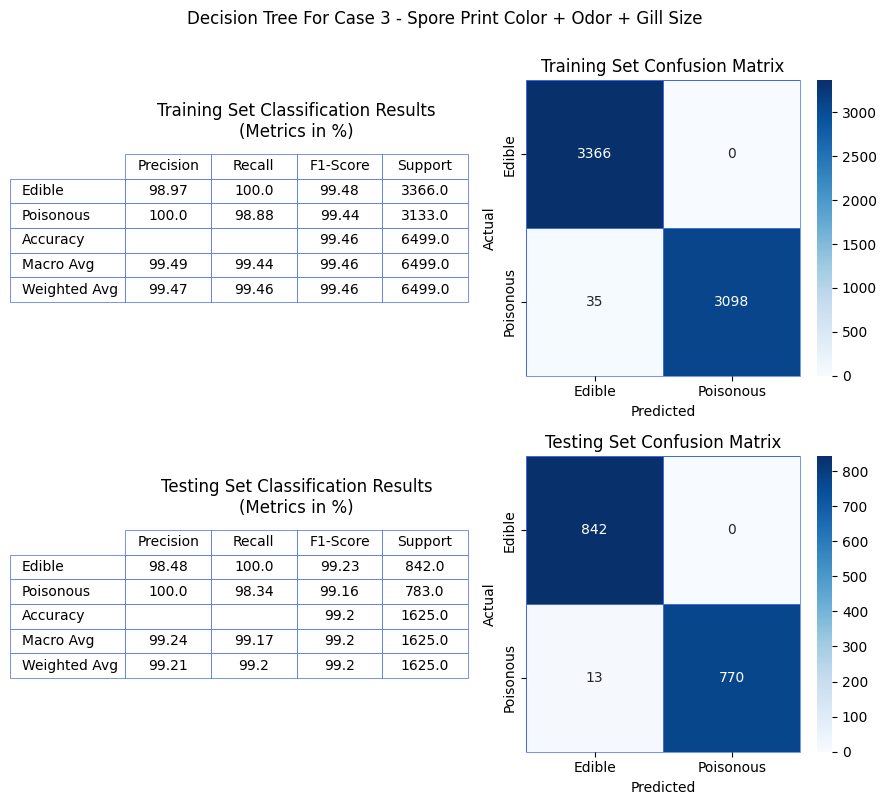

In [ ]:
tree_dict: dict = {
    "Spore Print Color": (tree_model1, (X1_train, X1_test)),
    "Spore Print Color + Odor": (tree_model2, (X2_train, X2_test)),
    "Spore Print Color + Odor + Gill Size": (tree_model3, (X3_train, X3_test))
}

for case_num, (case, (model, test_train)) in enumerate(tree_dict.items()):

    fig, axes = plt.subplots(nrows= 2, ncols= 2, figsize=(9, 8))

    for idx, X_tt in enumerate(test_train):

        y_pred = model.predict(X_tt)
        y_tt=y_train if idx == 0 else y_test
        title_tt: str = "Training" if idx==0 else "Testing"

        classification_table(y_tt, y_pred, axes[idx,0], target_names=["Edible", "Poisonous"])
        axes[idx,0].set_title(f"{title_tt} Set Classification Results\n(Metrics in %)", y=0.78)

        cm_nn3 = confusion_matrix(y_tt, y_pred)
        sns.heatmap(cm_nn3, annot=True, cmap="Blues", ax=axes[idx,1],
                    linewidths=.5, linecolor="royalblue", fmt="d")
        axes[idx,1].patch.set_edgecolor("royalblue")
        axes[idx,1].patch.set_linewidth(0.5)
        axes[idx,1].set(xlabel="Predicted", ylabel="Actual", title=f"{title_tt} Set Confusion Matrix")
        axes[idx,1].set_xticklabels(["Edible", "Poisonous"])
        axes[idx,1].set_yticklabels(["Edible", "Poisonous"])

    fig.suptitle(f"Decision Tree For Case {case_num+1} - {case}", y=1)
    plt.tight_layout()
    plt.show()
    fig.savefig("nn_classification_age_familysize.png", bbox_inches="tight")

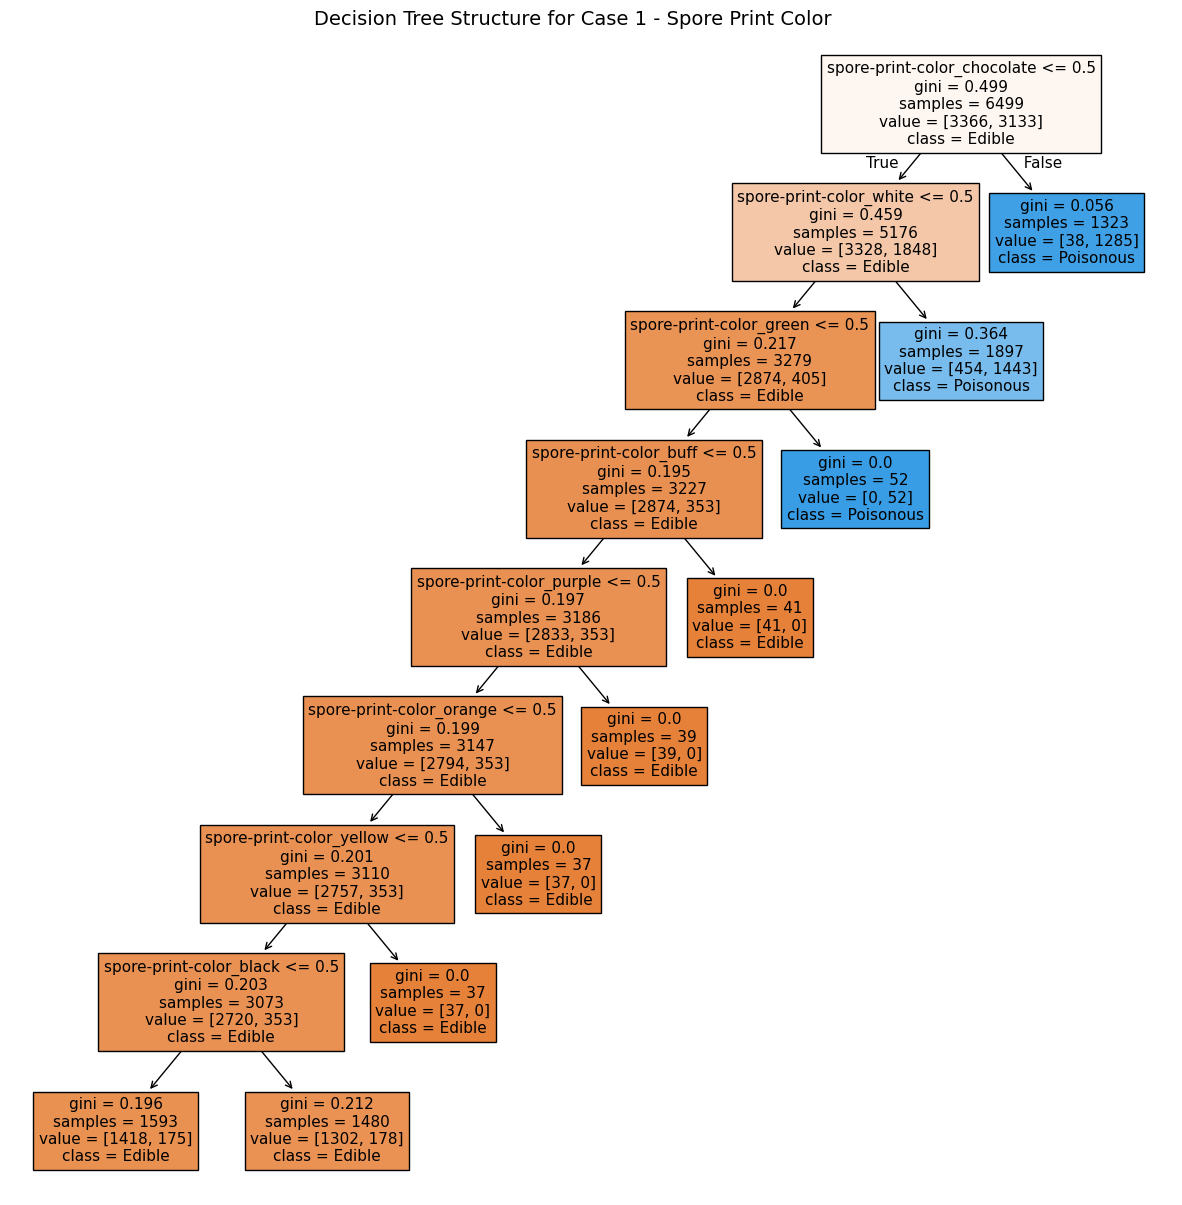

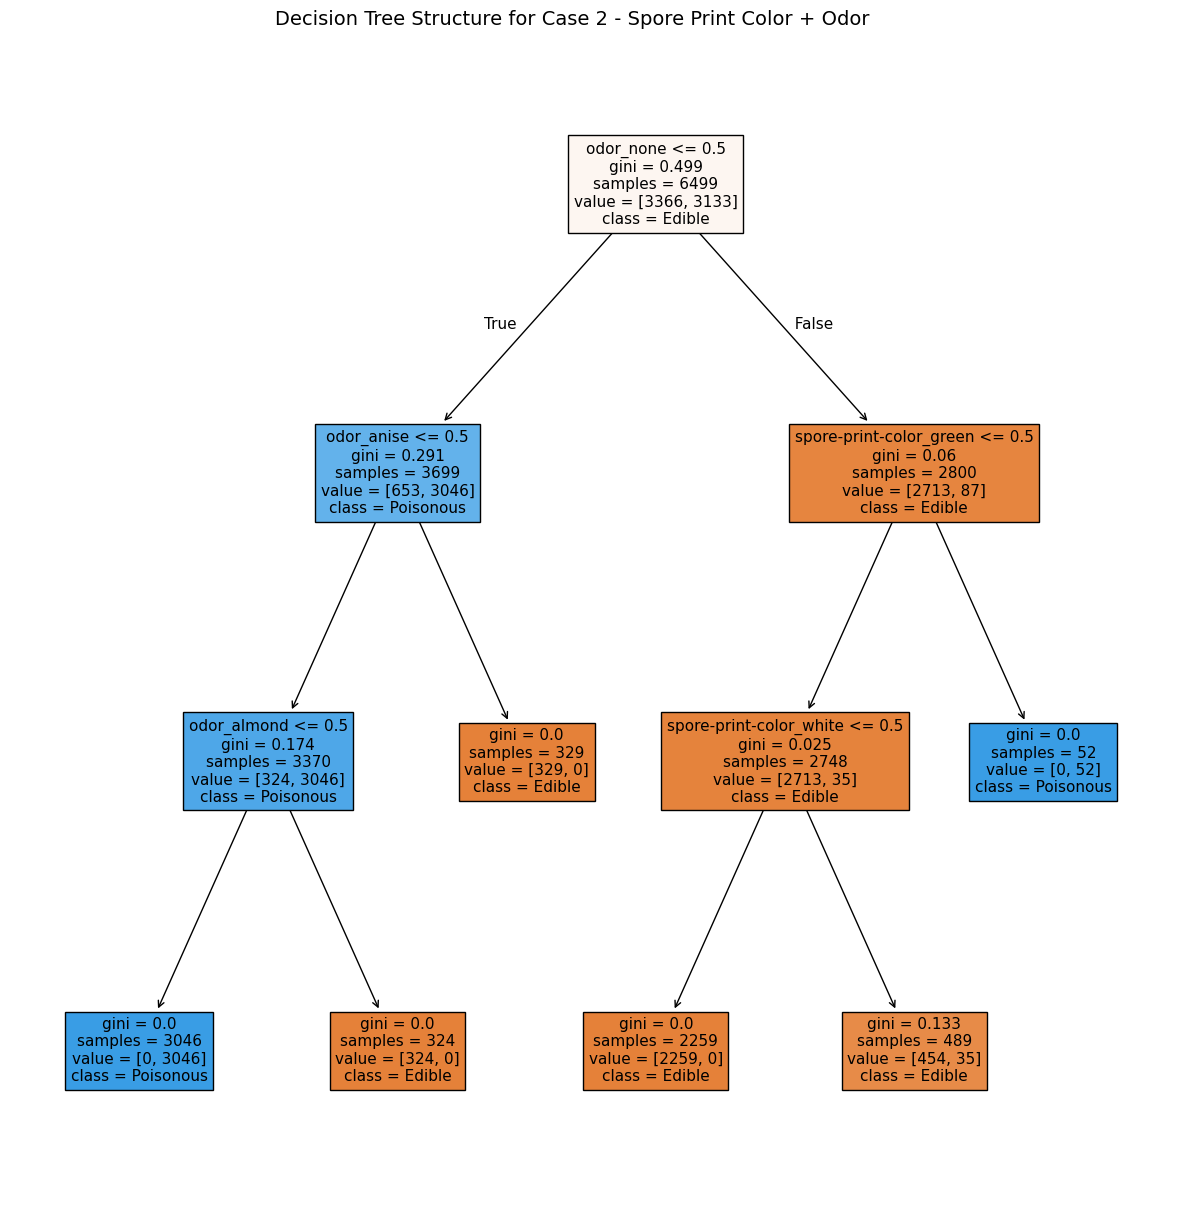

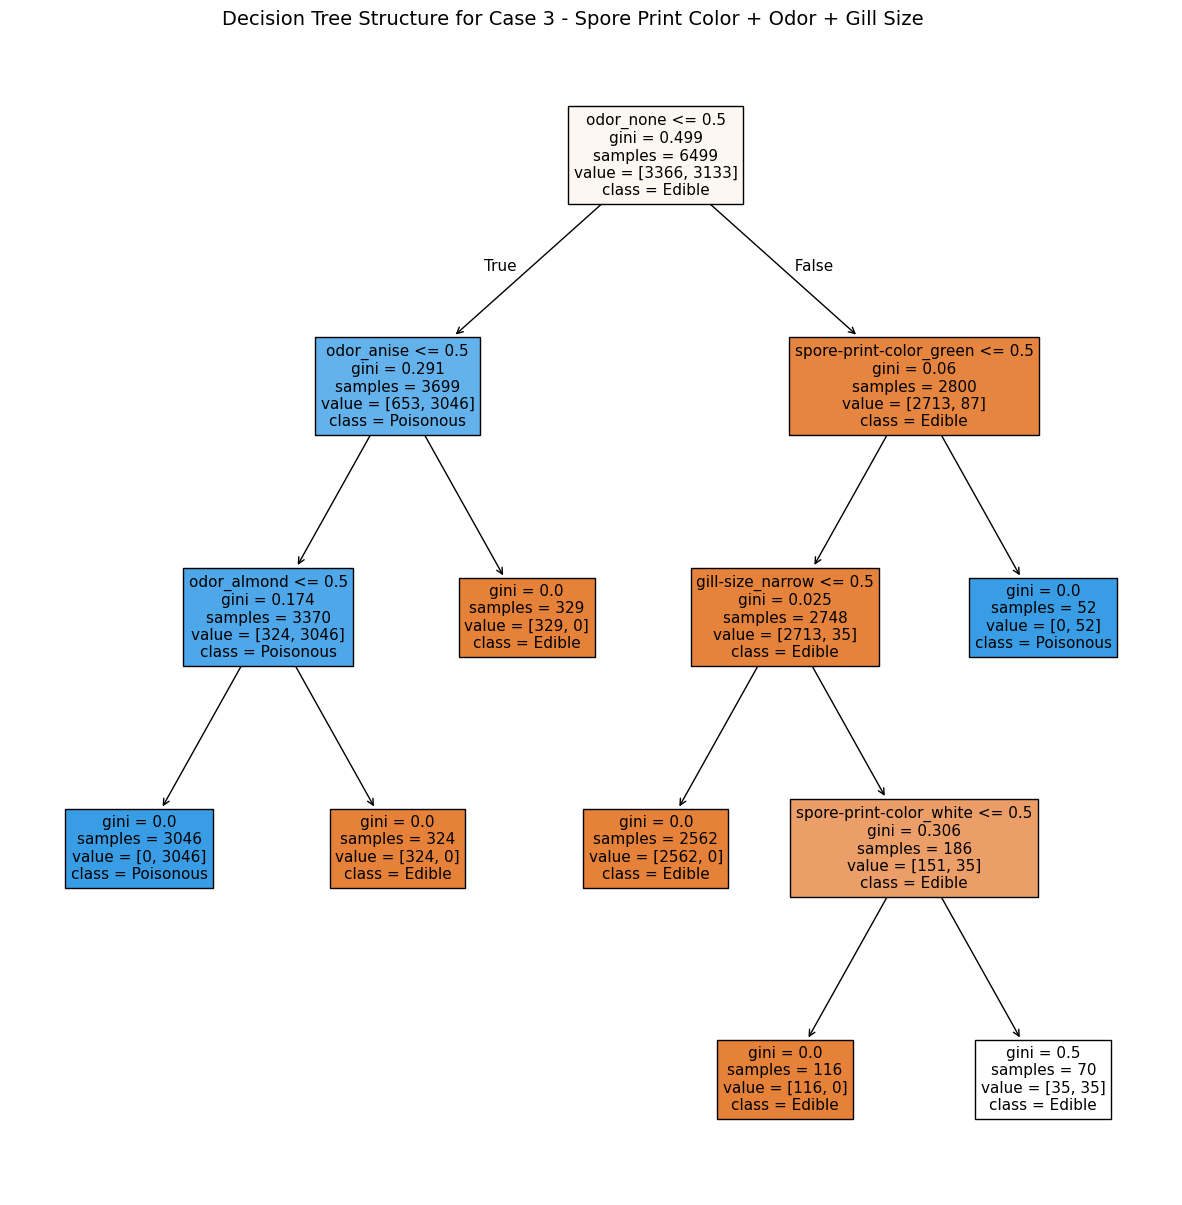

In [13]:
for case_num, (case_name, (model, (X_train, _))) in enumerate(tree_dict.items()):

    fig = plt.figure(figsize=(15,15))

    plot_tree(model,
              feature_names=X_train.columns.tolist(),
              class_names=["Edible", "Poisonous"],
              filled=True,
              fontsize=11
    )

    fig.suptitle(f"Decision Tree Structure for Case {case_num+1} - {case_name}", size=14, y=.9)
    plt.show()

### Reflection 4

How well did the model perform? Any surprises in the results?

## Section 5. Train and Evaluate Random Forest Models



### 5.1 Train and Evaluate Random Forest Models

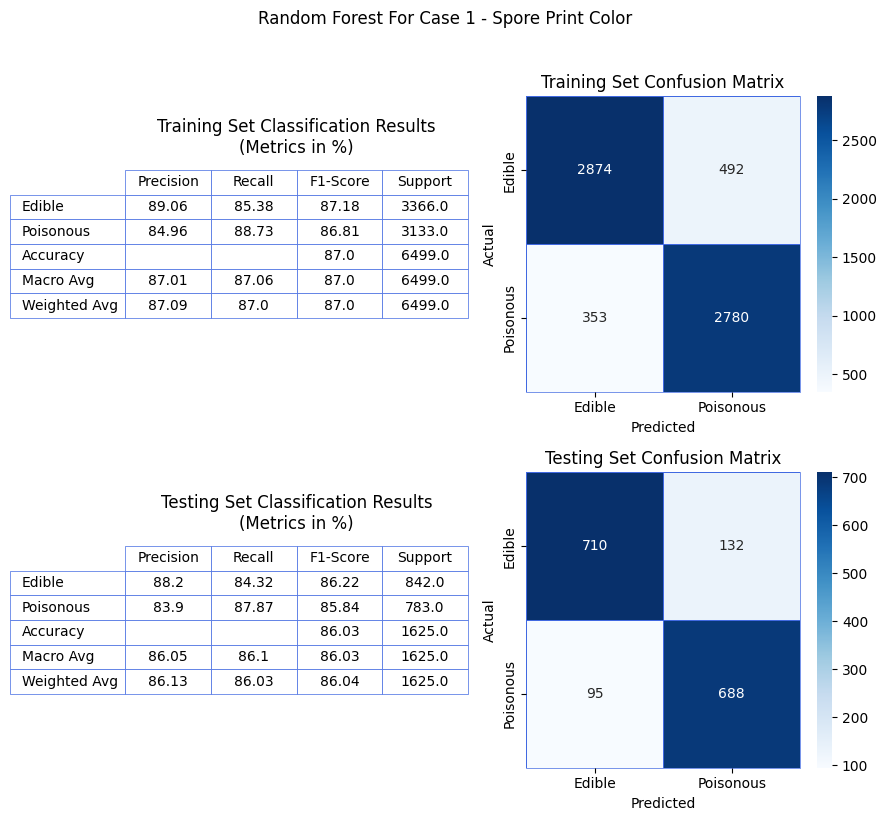

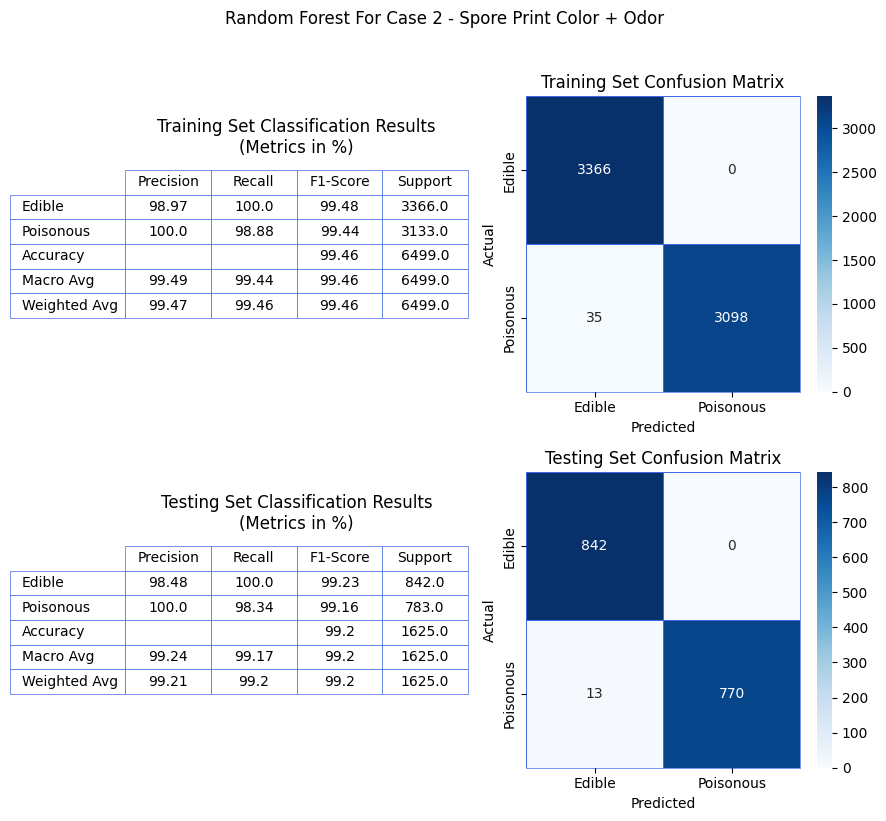

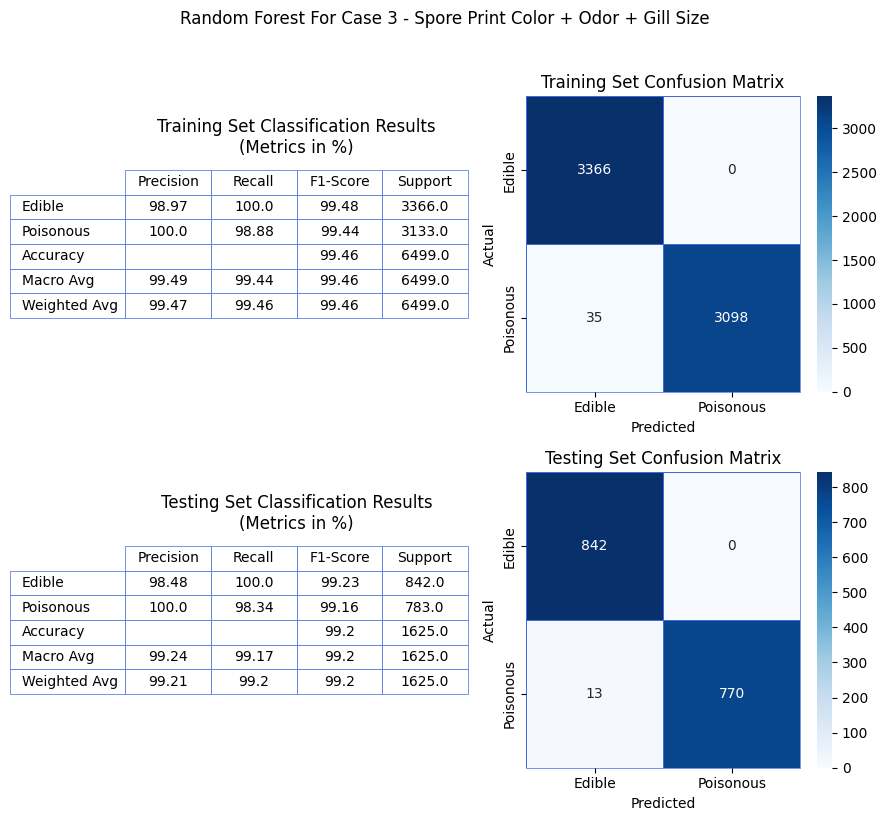

In [17]:
# CASE 1: Random Forest using Spore Print Color only
rf_model1 = RandomForestClassifier(random_state=123)
rf_model1.fit(X1_train, y_train)

# CASE 2: Random Forest using Spore Print Color + Odor
rf_model2 = RandomForestClassifier(random_state=123)
rf_model2.fit(X2_train, y_train)

# CASE 3: Random Forest using All 3 features
rf_model3 = RandomForestClassifier(random_state=123)
rf_model3.fit(X3_train, y_train)

rf_dict: dict = {
    "Spore Print Color": (rf_model1, (X1_train, X1_test)),
    "Spore Print Color + Odor": (rf_model2, (X2_train, X2_test)),
    "Spore Print Color + Odor + Gill Size": (rf_model3, (X3_train, X3_test))
}

for case_num, (case, (model, test_train)) in enumerate(rf_dict.items()):

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 8))

    for idx, X_tt in enumerate(test_train):

        y_pred = model.predict(X_tt)
        y_tt = y_train if idx == 0 else y_test
        title_tt: str = "Training" if idx == 0 else "Testing"

        classification_table(y_tt, y_pred, axes[idx,0], target_names=["Edible", "Poisonous"])
        axes[idx,0].set_title(f"{title_tt} Set Classification Results\n(Metrics in %)", y=0.78)

        cm = confusion_matrix(y_tt, y_pred)
        sns.heatmap(cm, annot=True, cmap="Blues", ax=axes[idx,1],
                    linewidths=.5, linecolor="royalblue", fmt="d")
        axes[idx,1].patch.set_edgecolor("royalblue")
        axes[idx,1].patch.set_linewidth(0.5)
        axes[idx,1].set(xlabel="Predicted", ylabel="Actual", title=f"{title_tt} Set Confusion Matrix")
        axes[idx,1].set_xticklabels(["Edible", "Poisonous"])
        axes[idx,1].set_yticklabels(["Edible", "Poisonous"])

    fig.suptitle(f"Random Forest For Case {case_num+1} - {case}", y=1.02)
    plt.tight_layout()
    plt.show()

### 5.2 Compare Performance of All Models

kdjsa;fj

### Reflection 5.

Which model performed better? Why might one classifier be more effective in this specific case?

## Section 6. Final Thoughts & Insights

### 6.1 Summarize Findings

### 6.2 Challenges Faced

6.3 If you had more time, what would you try next?

### Reflection 6.

What did you learn from this project?